Implement Ensemble Learning to combine different models

In [44]:
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import train_test_split,RepeatedKFold, cross_val_score,KFold, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier,export_graphviz
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn import model_selection

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz


In [45]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [46]:
print('Shape of the dataset', df.shape)

Shape of the dataset (768, 9)


In [47]:
df_copy = df.copy(deep = True)
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)
print('Number of zero entries in each attribute:\n')
print(df_copy.isnull().sum())

Number of zero entries in each attribute:

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [48]:
print('Imputing NaN values')
df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace = True)
df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean(), inplace = True)
df_copy['BMI'].fillna(df_copy['BMI'].mean(), inplace = True)
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median(), inplace = True)
df_copy['Insulin'].fillna(df_copy['Insulin'].median(), inplace = True)
print('Number of zero entries in each attribute:\n')
print(df_copy.isnull().sum())

Imputing NaN values
Number of zero entries in each attribute:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


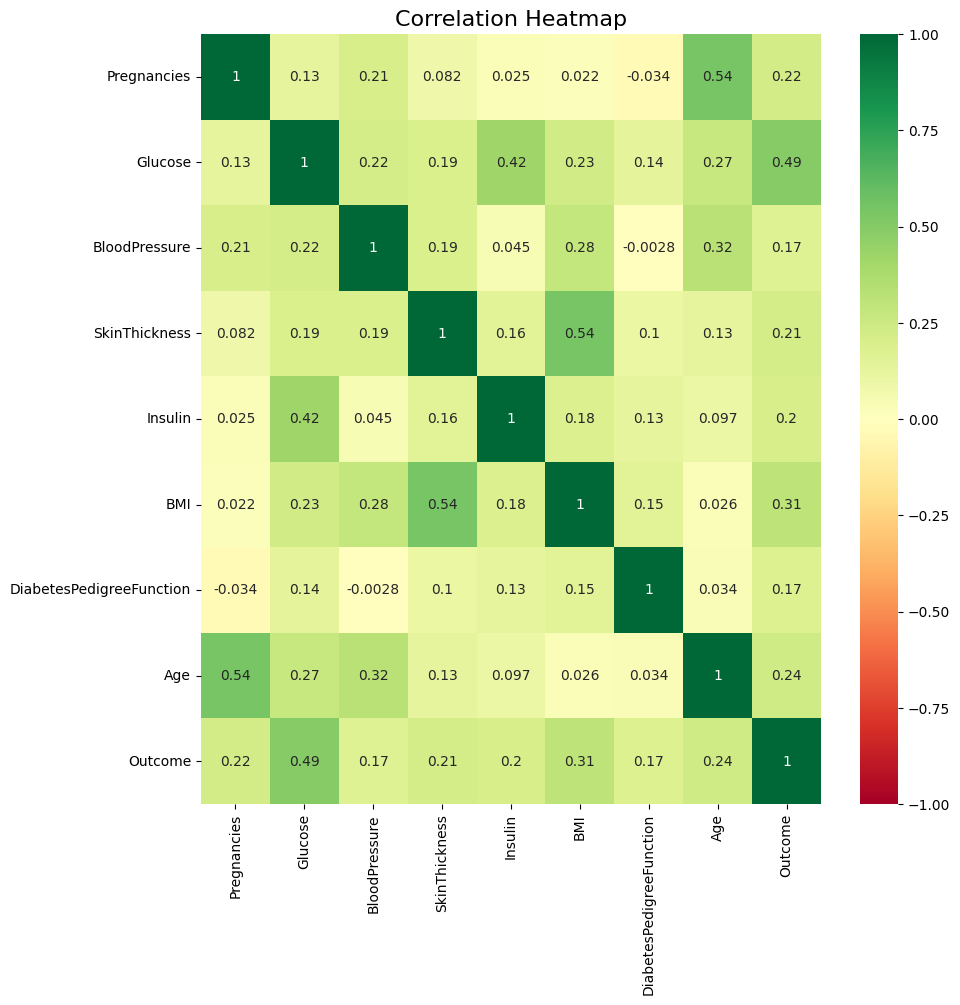

In [49]:
plt.figure(figsize=(10,10))
corr = df_copy.corr()
corr.index = df_copy.columns
sns.heatmap(corr, annot = True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [50]:
X = df_copy.iloc[:,0:8]
Y = df_copy.iloc[:,8]
seed = 7
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)


In [51]:
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

CV_N_REPEATS = 5

knn = KNeighborsClassifier(n_neighbors=11)

knn.fit(X_train, y_train)

scores = cross_val_score(knn, X, Y, cv=RepeatedStratifiedKFold(n_repeats=CV_N_REPEATS))

print(f"Accuracy mean={scores.mean():0.2f} +/- {scores.std():0.2f} (1 s.d.)")


Accuracy mean=0.74 +/- 0.03 (1 s.d.)


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

model = KNeighborsClassifier(n_neighbors=11)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("RMSE on training data:", rmse_train)
print("MAPE on training data:", mape_train)
print("RMSE on testing data:", rmse_test)
print("MAPE on testing data:", mape_test)

if rmse_train < rmse_test:
    print("The model is likely overfitting because RMSE on training data is lower than on testing data.")
elif rmse_train > rmse_test:
    print("The model is likely underfitting because RMSE on training data is higher than on testing data.")
else:
    print("The model has a balanced fit on both training and testing data.")

if mape_train < mape_test:
    print("The model may have a bias issue because MAPE on training data is lower than on testing data.")
elif mape_train > mape_test:
    print("The model may have a variance issue because MAPE on training data is higher than on testing data.")
else:
    print("The model has a balanced fit on both training and testing data.")

RMSE on training data: 0.4530030092442707
MAPE on training data: inf
RMSE on testing data: 0.5096471914376255
MAPE on testing data: inf
The model is likely overfitting because RMSE on training data is lower than on testing data.
The model has a balanced fit on both training and testing data.


In [53]:
dt=DecisionTreeClassifier(random_state=1, max_depth=2)
dt=dt.fit(X_train,y_train)
dt_scores = cross_val_score(dt, X, Y, cv=RepeatedStratifiedKFold(n_repeats=CV_N_REPEATS))
print(f"Accuracy mean={dt_scores.mean():0.2f} +/- {dt_scores.std():0.2f} (1 s.d.)")

Accuracy mean=0.74 +/- 0.03 (1 s.d.)


In [54]:
model = DecisionTreeClassifier(random_state=1, max_depth=2)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("RMSE on training data:", rmse_train)
print("MAPE on training data:", mape_train)
print("RMSE on testing data:", rmse_test)
print("MAPE on testing data:", mape_test)

if rmse_train < rmse_test:
    print("The model is likely overfitting because RMSE on training data is lower than on testing data.")
elif rmse_train > rmse_test:
    print("The model is likely underfitting because RMSE on training data is higher than on testing data.")
else:
    print("The model has a balanced fit on both training and testing data.")

if mape_train < mape_test:
    print("The model may have a bias issue because MAPE on training data is lower than on testing data.")
elif mape_train > mape_test:
    print("The model may have a variance issue because MAPE on training data is higher than on testing data.")
else:
    print("The model has a balanced fit on both training and testing data.")

RMSE on training data: 0.4775070987074024
MAPE on training data: inf
RMSE on testing data: 0.48349377841522817
MAPE on testing data: inf
The model is likely overfitting because RMSE on training data is lower than on testing data.
The model has a balanced fit on both training and testing data.


Accuracy of Random Forest Classifier: 75.97%


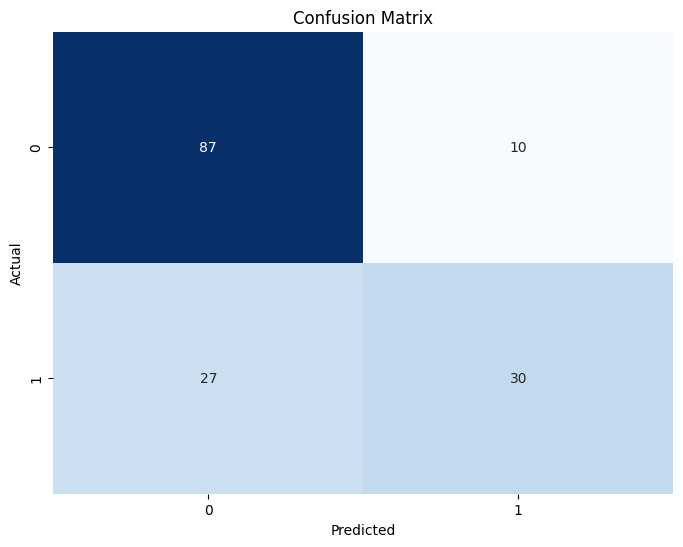

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

num_estimators = 10
rf = RandomForestClassifier(n_estimators=num_estimators)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
rf_score = accuracy_score(y_test, y_pred)
print("Accuracy of Random Forest Classifier: {0:0.2f}%".format(rf_score * 100.0))

confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [56]:
model = RandomForestClassifier(n_estimators=num_estimators)
model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("RMSE on training data:", rmse_train)
print("MAPE on training data:", mape_train)
print("RMSE on testing data:", rmse_test)
print("MAPE on testing data:", mape_test)

if rmse_train < rmse_test:
    print("The model is likely overfitting because RMSE on training data is lower than on testing data.")
elif rmse_train > rmse_test:
    print("The model is likely underfitting because RMSE on training data is higher than on testing data.")
else:
    print("The model has a balanced fit on both training and testing data.")

if mape_train < mape_test:
    print("The model may have a bias issue because MAPE on training data is lower than on testing data.")
elif mape_train > mape_test:
    print("The model may have a variance issue because MAPE on training data is higher than on testing data.")
else:
    print("The model has a balanced fit on both training and testing data.")

RMSE on training data: 0.4775070987074024
MAPE on training data: inf
RMSE on testing data: 0.4629100498862757
MAPE on testing data: inf
The model is likely underfitting because RMSE on training data is higher than on testing data.
The model has a balanced fit on both training and testing data.


In [57]:
from xgboost import XGBClassifier, plot_importance,to_graphviz

# fit model on training data
param = {'max_depth': 5, 'eta': 0.8, 'subsample':1, 'objective': 'binary:logistic'}
xgb = XGBClassifier(**param)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.8, eval_metric=None,
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, ...)

Accuracy of XGB Classifier: 75.32%


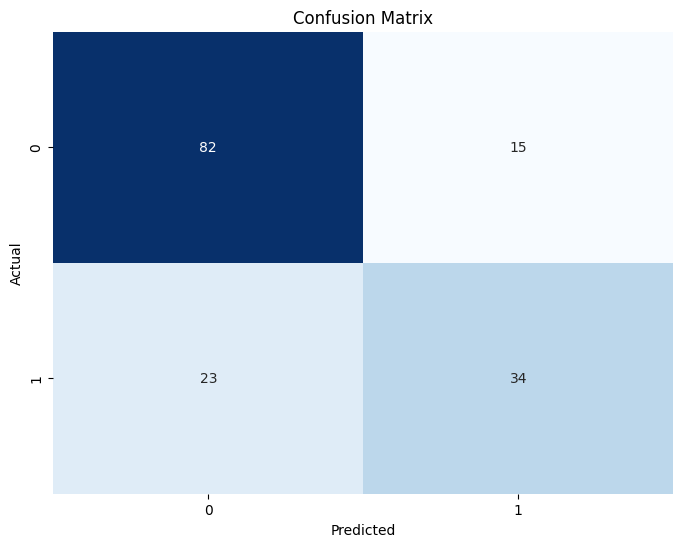

In [58]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Create and fit the XGBoost Classifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Make predictions for the test data
y_pred = xgb.predict(X_test)

# Evaluate the model's accuracy
xgb_score = accuracy_score(y_test, y_pred)
print("Accuracy of XGB Classifier: {0:0.2f}%".format(xgb_score * 100.0))

# Create a confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

model = XGBClassifier()

model.fit(X_train, y_train)

# Make predictions on both training and testing data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate RMSE and MAPE on training data
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Calculate RMSE and MAPE on testing data
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# Print RMSE and MAPE on training and testing data
print("RMSE on training data:", rmse_train)
print("MAPE on training data:", mape_train)
print("RMSE on testing data:", rmse_test)
print("MAPE on testing data:", mape_test)

# Comment on overfitting/underfitting/bias/variance
if rmse_train < rmse_test:
    print("The model is likely overfitting because RMSE on training data is lower than on testing data.")
elif rmse_train > rmse_test:
    print("The model is likely underfitting because RMSE on training data is higher than on testing data.")
else:
    print("The model has a balanced fit on both training and testing data.")

if mape_train < mape_test:
    print("The model may have a bias issue because MAPE on training data is lower than on testing data.")
elif mape_train > mape_test:
    print("The model may have a variance issue because MAPE on training data is higher than on testing data.")
else:
    print("The model has a balanced fit on both training and testing data.")

RMSE on training data: 0.0
MAPE on training data: 0.0
RMSE on testing data: 0.496742636335202
MAPE on testing data: inf
The model is likely overfitting because RMSE on training data is lower than on testing data.
The model may have a bias issue because MAPE on training data is lower than on testing data.


In [60]:
from mlxtend.classifier import StackingCVClassifier

sclf = StackingCVClassifier(classifiers=[knn, rf, xgb],
                          meta_classifier=rf)

print('10-fold cross validation:\n')

for clf, label in zip([knn, rf, xgb, rf],
                      ['KNearest Neighbors',
                       'Random Forest',
                        'XGB',
                       'MetaClassifier']):

    sclf_scores = model_selection.cross_val_score(clf, X, Y,
                                              cv=10, scoring='accuracy')
    print("Accuracy: %0.2f (+/- %0.2f) [%s]" % (sclf_scores.mean(), sclf_scores.std(), label))

10-fold cross validation:

Accuracy: 0.74 (+/- 0.05) [KNearest Neighbors]
Accuracy: 0.75 (+/- 0.05) [Random Forest]
Accuracy: 0.73 (+/- 0.04) [XGB]
Accuracy: 0.73 (+/- 0.04) [MetaClassifier]
